# Dupuit-Forchheimer vs. Di Ciacci et al. (2019) vs. MODFLOW-style streambed resistance

This notebook compares groundwater-to-surface-water parameterizations.

- **Dupuit-Forchheimer**: the conductance grows with saturated thickness, so the sink increases nonlinearly with head above the streambed.
- **Di Ciacci et al. (2019)**: the flux is represented with a resistance network through the stream bed, aquifer, and radial aquifer domain.
- **MODFLOW-style streambed resistance (here)**: same conductance form as Dupuit, but with streambed conductivity and streambed thickness as the controlling resistance scale.

The Dupuit-Forchheimer form used here is:

$$
C_{dd} = K_{hor}\,\frac{L_{sw}}{L}\,(h_{GW}-h_{SW}), \qquad
q_{GW\to SW} = \frac{C_{dd}\,(h_{GW}-h_{SW})}{L_{avg}^{2}}
$$

which is equivalent to:

$$
q_{GW\to SW} = \frac{K_{hor}\,L_{sw}}{L\,L_{avg}^{2}}\,(h_{GW}-h_{SW})^{2},
$$

In this Dupuit-Forchheimer setup, resistance is assumed to occur horizontally in the aquifer only (no explicit streambed resistance term).

The MODFLOW-style streambed-resistance form used here is:

$$
C_{dd,\mathrm{mf}} = K_{sb}\,\frac{L_{sw}}{M_{sb}}\,(h_{GW}-h_{SW}), \qquad
q_{GW\to SW,\mathrm{mf}} = \frac{C_{dd,\mathrm{mf}}\,(h_{GW}-h_{SW})}{L_{avg}^{2}}
$$

which is equivalent to:

$$
q_{GW\to SW,\mathrm{mf}} = \frac{K_{sb}\,L_{sw}}{M_{sb}\,L_{avg}^{2}}\,(h_{GW}-h_{SW})^{2}.
$$

With $D_{avg}=D$, the Di Ciacci et al. (2019) resistance used here is:

$$
\gamma_{3D,\mathrm{meta}}
=
\frac{M_{sb}}{K_{sb} W_{sb} L_{sw}}
+
\frac{3 L L_{avg} - L_{avg}^{2}}{24\,L\,K_{hor}\,D\,L_{sw}}
+
\frac{\ln(D/u)}{\pi\,\sqrt{K_{hor}K_{ver}}\,L_{sw}}
$$

(the radial term remains, but without discretization damping).

The equivalent conductance form is:

$$
C_{\mathrm{meta}} = \frac{1}{\gamma_{3D,\mathrm{meta}}}
$$

and the exchange can be written as:

$$
q_{GW\to SW,\mathrm{dc}} = \frac{C_{\mathrm{meta}}\,(h_{GW}-h_{SW})}{L_{avg}^{2}}, \qquad
Q_{GW\to SW,\mathrm{dc}} = C_{\mathrm{meta}}\,(h_{GW}-h_{SW}).
$$

So Di Ciacci can also be interpreted as a series-conductance model:

$$
\frac{1}{C_{\mathrm{meta}}} = \frac{1}{C_{sb}} + \frac{1}{C_{aq}} + \frac{1}{C_{rad}}.
$$

The notebook uses dummy heads and geometry so the approaches can be compared without running the full groundwater solver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


eps = np.finfo(float).eps


def dupuit_forchheimer_flux(head, bed_head, L, L_avg, D, Wsb, Lsw, Msb, Ksb, Khor, Kver, u, cell_size):
    """Cell sink rate [m d-1] in Dupuit form, using Di Ciacci-style argument naming."""
    sat_thickness = np.maximum(0.0, head - bed_head)
    conductance = Khor * Lsw * sat_thickness / L
    active = (bed_head < -eps) & (head > bed_head)
    return np.where(active, conductance * (head - bed_head) / cell_size**2, 0.0)


def modflow_streambed_flux(head, bed_head, L, L_avg, D, Wsb, Lsw, Msb, Ksb, Khor, Kver, u, cell_size):
    """Cell sink rate [m d-1] with streambed-controlled resistance, using Di Ciacci-style argument naming."""
    sat_thickness = np.maximum(0.0, head - bed_head)
    conductance = Ksb * Lsw * sat_thickness / Msb
    active = (bed_head < -eps) & (head > bed_head)
    return np.where(active, conductance * (head - bed_head) / cell_size**2, 0.0)


def di_ciacci_flux(head, bed_head, L, L_avg, D, Wsb, Lsw, Msb, Ksb, Khor, Kver, u, cell_size):
    """Cell sink rate [m d-1] using the Di Ciacci et al. (2019) metamodel resistance, with D_avg = D."""
    active = (bed_head < -eps) & (head > bed_head)

    # Enforce non-negative resistance components.
    gamma_sb = np.maximum(0.0, Msb / (Ksb * Wsb * Lsw))
    gamma_aquifer = np.maximum(0.0, (3.0 * L * L_avg - L_avg**2) / (24.0 * L * Khor * D * Lsw))
    gamma_radial = np.maximum(0.0, np.log(D / u) / (np.pi * np.sqrt(Khor * Kver) * Lsw))

    gamma_meta = np.maximum(gamma_sb + gamma_aquifer + gamma_radial, eps)
    return np.where(active, (head - bed_head) / gamma_meta / cell_size**2, 0.0)

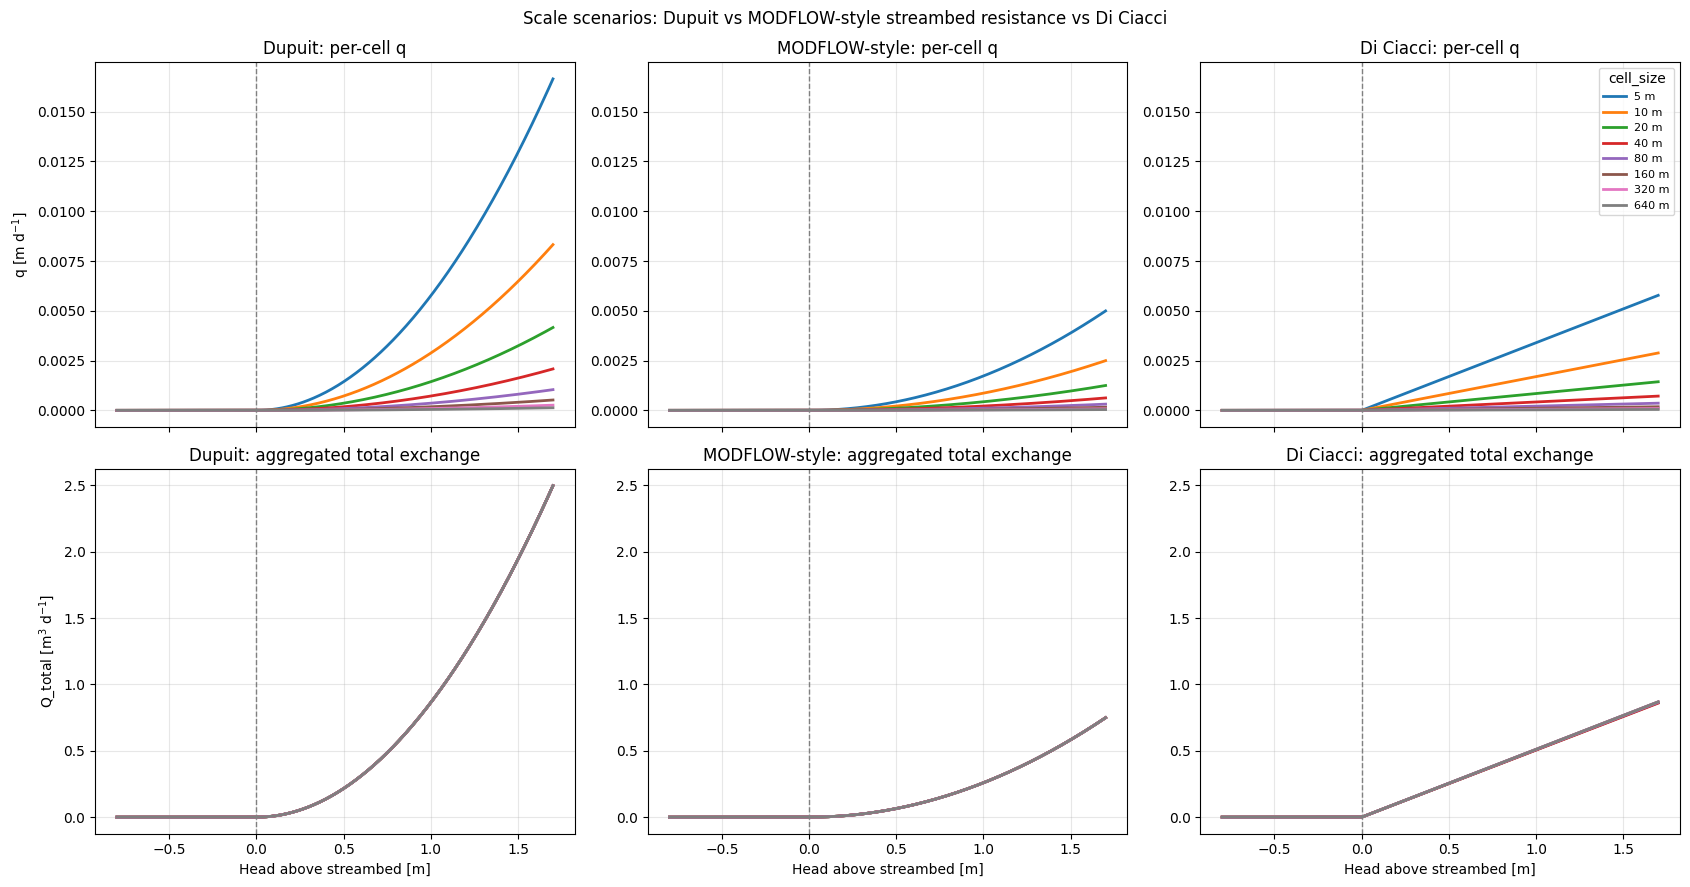

In [2]:
# Aggregated comparison across scale scenarios
# 1) per-cell sink rate q [m d-1]
# 2) total exchange volume per representative domain width [m3 d-1]
#    computed as q * cell_area * n_cells, with n_cells = L / cell_size

# Dummy geometry and hydraulic parameters.
# Values are chosen for visualization, not calibration.
L = 30.0                      # distance between two surface-water bodies [m]
L_avg = 10.0                  # horizontal discretization [m]
D = 5.0                       # aquifer thickness [m]
Wsb = 2.0                     # streambed width [m]
Lsw = 10.0                    # length of surface water in a cell [m]
Msb = 0.10                    # streambed thickness [m]
u = 1.2 * Wsb                 # wetted perimeter [m]
Ksb = 1e-8 * 86400.0          # streambed hydraulic conductivity [m d-1]
Khor = 1e-5 * 86400.0         # aquifer horizontal hydraulic conductivity [m d-1]
Kver = 1e-6 * 86400.0         # aquifer vertical hydraulic conductivity [m d-1]

# Streambed / ditch water level and a sweep of groundwater heads.
streambed_head = -0.20
head = np.linspace(-1.0, 1.5, 500)

# Scenario sweep: keep L_avg == cell_size and Lsw == cell_size
cell_sizes = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0, 320.0, 640.0]
head_diff = head - streambed_head

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)

for cs in cell_sizes:
    L_avg_s = cs
    Lsw_s = cs
    cell_size_s = cs

    common_kwargs = dict(
        head=head,
        bed_head=streambed_head,
        L=L,
        L_avg=L_avg_s,
        D=D,
        Wsb=Wsb,
        Lsw=Lsw_s,
        Msb=Msb,
        Ksb=Ksb,
        Khor=Khor,
        Kver=Kver,
        u=u,
        cell_size=cell_size_s,
    )

    q_dupuit = dupuit_forchheimer_flux(**common_kwargs)
    q_modflow = modflow_streambed_flux(**common_kwargs)
    q_diciacci = di_ciacci_flux(**common_kwargs)

    # Per-cell rate [m d-1]
    axes[0, 0].plot(head_diff, q_dupuit, lw=2, label=f'{cs:.0f} m')
    axes[0, 1].plot(head_diff, q_modflow, lw=2, label=f'{cs:.0f} m')
    axes[0, 2].plot(head_diff, q_diciacci, lw=2, label=f'{cs:.0f} m')

    # Aggregated total exchange [m3 d-1] over a representative strip of width 1 m
    n_cells = L / cell_size_s
    cell_area = cell_size_s**2
    qtot_dupuit = q_dupuit * cell_area * n_cells
    qtot_modflow = q_modflow * cell_area * n_cells
    qtot_diciacci = q_diciacci * cell_area * n_cells

    axes[1, 0].plot(head_diff, qtot_dupuit, lw=2, label=f'{cs:.0f} m')
    axes[1, 1].plot(head_diff, qtot_modflow, lw=2, label=f'{cs:.0f} m')
    axes[1, 2].plot(head_diff, qtot_diciacci, lw=2, label=f'{cs:.0f} m')

# Match y-limits within each row for direct side-by-side comparison.
for row in [0, 1]:
    y_min = min(ax.get_ylim()[0] for ax in axes[row, :])
    y_max = max(ax.get_ylim()[1] for ax in axes[row, :])
    for ax in axes[row, :]:
        ax.set_ylim(y_min, y_max)

axes[0, 0].set_title('Dupuit: per-cell q')
axes[0, 1].set_title('MODFLOW-style: per-cell q')
axes[0, 2].set_title('Di Ciacci: per-cell q')
axes[1, 0].set_title('Dupuit: aggregated total exchange')
axes[1, 1].set_title('MODFLOW-style: aggregated total exchange')
axes[1, 2].set_title('Di Ciacci: aggregated total exchange')

for ax in axes.ravel():
    ax.axvline(0.0, color='0.5', ls='--', lw=1)
    ax.grid(True, alpha=0.3)

axes[0, 0].set_ylabel('q [m d$^{-1}$]')
axes[1, 0].set_ylabel('Q_total [m$^3$ d$^{-1}$]')
for col in [0, 1, 2]:
    axes[1, col].set_xlabel('Head above streambed [m]')
axes[0, 2].legend(title='cell_size', fontsize=8)

fig.suptitle('Scale scenarios: Dupuit vs MODFLOW-style streambed resistance vs Di Ciacci')
fig.tight_layout()
plt.show()